# RCM Project — 03: Baseline Model (Logistic Regression)

**Stage:** 3 of 5  
**Input:** `data/processed/features_*.parquet`  
**Output:** `outputs/models/baseline_lr.joblib`, `outputs/reports/baseline_report.json`

## Goals
1. Train class-weighted Logistic Regression (interpretable benchmark)
2. Evaluate: ROC-AUC, PR-AUC, calibration, confusion matrix
3. Business cost model threshold optimisation
4. Top coefficient analysis
5. Document baseline for comparison with advanced models


## 0. Setup

In [1]:
# Cell 1/2 — imports (takes ~10s on first run, just let it load)
import sys, warnings, json, time, threading
from pathlib import Path
from IPython.display import clear_output

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)
print('Imports done ✓')


Imports done ✓


In [2]:
# Cell 2/2 — config & paths (fast, progress bar visible)
def show_progress(step, total, label, width=38):
    filled = int(width * step / total)
    bar = '█' * filled + '░' * (width - filled)
    clear_output(wait=True)
    print(f'[{bar}] {step}/{total}  {label}')

show_progress(1, 4, 'Resolving project root...')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

show_progress(2, 4, 'Loading config...')
from src.utils.config_loader import get_config
cfg     = get_config()
SEED    = cfg.project.random_seed
FIGURES = ROOT / cfg.paths.figures
MODELS  = ROOT / cfg.paths.models
REPORTS = ROOT / cfg.paths.reports
PROC    = ROOT / cfg.paths.data_processed
for p in [FIGURES, MODELS, REPORTS]: p.mkdir(parents=True, exist_ok=True)

show_progress(3, 4, 'Setting cost model...')
FN_COST = cfg.evaluation.cost_model.avg_claim_amount * cfg.evaluation.cost_model.intervention_success_rate
FP_COST = cfg.evaluation.cost_model.review_cost

show_progress(4, 4, 'Verifying feature files...')
missing = [f for f in ['features_train.parquet','features_val.parquet','features_test.parquet']
           if not (PROC / f).exists()]
if missing:
    raise FileNotFoundError(f'Run Notebook 02 first. Missing: {missing}')

print(f'\n  FN cost : ${FN_COST:.0f}  |  FP cost : ${FP_COST:.0f}')
print(f'  Seed    : {SEED}')
print(f'  Data    : {PROC}')


[██████████████████████████████████████] 4/4  Verifying feature files...

  FN cost : $300  |  FP cost : $25
  Seed    : 42
  Data    : C:\Users\Aasir Waseer\Desktop\Aasir\MDS_AI\3_Sem\rcm_project\data\processed


## 1. Load Feature Sets

In [3]:
train_df = pd.read_parquet(PROC / 'features_train.parquet')
val_df   = pd.read_parquet(PROC / 'features_val.parquet')
test_df  = pd.read_parquet(PROC / 'features_test.parquet')
print(f'Train : {train_df.shape}')
print(f'Val   : {val_df.shape}')
print(f'Test  : {test_df.shape}')


Train : (46693, 65)
Val   : (10006, 65)
Test  : (10006, 65)


In [4]:
LABEL = 'DENIED'
X_train = train_df.drop(columns=[LABEL])
y_train = train_df[LABEL].values
X_val   = val_df.drop(columns=[LABEL])
y_val   = val_df[LABEL].values
X_test  = test_df.drop(columns=[LABEL])
y_test  = test_df[LABEL].values

for X in [X_train, X_val, X_test]:
    for col in X.select_dtypes(include='Int64').columns:
        X[col] = X[col].astype(float)

print(f'Train : {X_train.shape}  |  Denied: {y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Val   : {X_val.shape}  |  Denied: {y_val.sum():,} ({y_val.mean()*100:.2f}%)')
print(f'Test  : {X_test.shape}  |  Denied: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')

# Leakage guard — label = BENRES_OP > $670
# All annual cost-sharing columns must be absent (they're complements of the label)
FORBIDDEN = ['CLM_PMT_AMT', 'CLM_PMT_AMT_LOG',
             'BENRES_OP', 'BENRES_IP',
             'MEDREIMB_OP', 'MEDREIMB_IP',
             'PPPYMT_OP', 'PPPYMT_IP',
             'IS_SECONDARY_PAYER']
leaked = [c for c in FORBIDDEN if c in X_train.columns]
if leaked:
    raise ValueError(
        f'Leaky features detected — re-run NB02 with updated engineer.py: {leaked}'
    )
print(f'Leakage check passed ✓  ({X_train.shape[1]} features)')
print(f'Features: {X_train.columns.tolist()}')


Train : (46693, 64)  |  Denied: 10,708 (22.93%)
Val   : (10006, 64)  |  Denied: 1,780 (17.79%)
Test  : (10006, 64)  |  Denied: 1,559 (15.58%)
Leakage check passed ✓  (64 features)
Features: ['IS_INPATIENT', 'CLAIM_DURATION_DAYS', 'HAS_SECONDARY_DX', 'HAS_TERTIARY_DX', 'HAS_HCPCS', 'HCPCS_CODE_COUNT', 'BENE_AGE_AT_CLAIM', 'BENE_SEX', 'BENE_RACE', 'BENE_ESRD', 'COMORBIDITY_COUNT', 'HI_CVRAGE_MONS', 'SMI_CVRAGE_MONS', 'HMO_CVRAGE_MONS', 'SP_STATE_CODE', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA', 'PRVDR_DENIAL_RATE_HIST', 'PRVDR_CLAIM_VOLUME_LOG', 'ICD_CHAPTER_DENIAL_RATE', 'BENE_DENIAL_RATE_30D', 'BENE_DENIAL_RATE_60D', 'BENE_DENIAL_RATE_90D', 'CLAIM_MONTH', 'CLAIM_DOW', 'CLAIM_YEAR', 'CLAIM_QUARTER', 'CLAIM_DAY_OF_YEAR', 'IS_WEEKEND', 'IS_Q4', 'MONTH_SIN', 'MONTH_COS', 'DOW_SIN', 'DOW_COS', 'DAYS_SINCE_START', 'ICD_TYPE_DENIAL_RATE', 'IS_HIGH_RISK_PROVIDER', 'ICD_CH_blood', 'ICD_CH_c

## 2. Train Logistic Regression

In [5]:
print(f'Class imbalance: {(y_train==0).sum():,} accepted  vs  {(y_train==1).sum():,} denied')
print(f'scale factor   : {(y_train==0).sum()/(y_train==1).sum():.1f}×')
print()

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=cfg.modeling.logistic_regression.C,
        random_state=SEED,
        solver='lbfgs',
        verbose=0,
    ))
])

done = [False]
def animate():
    frames = ['⠋','⠙','⠹','⠸','⠼','⠴','⠦','⠧','⠇','⠏']
    i = 0
    while not done[0]:
        clear_output(wait=True)
        print(f'{frames[i%len(frames)]}  Fitting Logistic Regression ...')
        print(f'    (lbfgs solver, max_iter=1000, balanced weights)')
        print(f'    Typically 1–3 min on 600K rows.')
        time.sleep(0.4); i += 1

t = threading.Thread(target=animate, daemon=True)
t.start(); t0 = time.time()
lr_pipeline.fit(X_train, y_train)
done[0] = True; t.join(timeout=1)
clear_output(wait=True)

elapsed = time.time() - t0
n_iter  = lr_pipeline.named_steps['lr'].n_iter_[0]
print(f'✓ Training complete  |  {n_iter} iterations  |  {elapsed:.1f}s')


✓ Training complete  |  28 iterations  |  0.4s


## 3. Score Distribution

Val  score range: [0.0000, 1.0000]
Test score range: [0.0000, 1.0000]


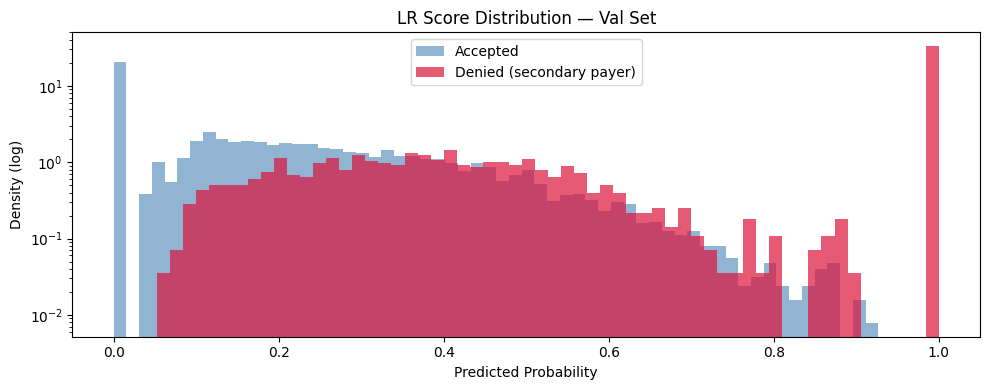

In [6]:
y_val_prob  = lr_pipeline.predict_proba(X_val)[:,1]
y_test_prob = lr_pipeline.predict_proba(X_test)[:,1]

print(f'Val  score range: [{y_val_prob.min():.4f}, {y_val_prob.max():.4f}]')
print(f'Test score range: [{y_test_prob.min():.4f}, {y_test_prob.max():.4f}]')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_val_prob[y_val==0], bins=60, alpha=0.6, color='steelblue',
        label='Accepted', density=True, log=True)
ax.hist(y_val_prob[y_val==1], bins=60, alpha=0.7, color='crimson',
        label='Denied (secondary payer)', density=True, log=True)
ax.set_title('LR Score Distribution — Val Set')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density (log)')
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES / '12_lr_score_dist.png', dpi=150)
plt.show()


## 4. ROC-AUC & PR-AUC

ROC-AUC  : 0.8984  (random = 0.50)
PR-AUC   : 0.7722  (random = 0.1779)
PR lift  : 4.34×
Brier    : 0.0923


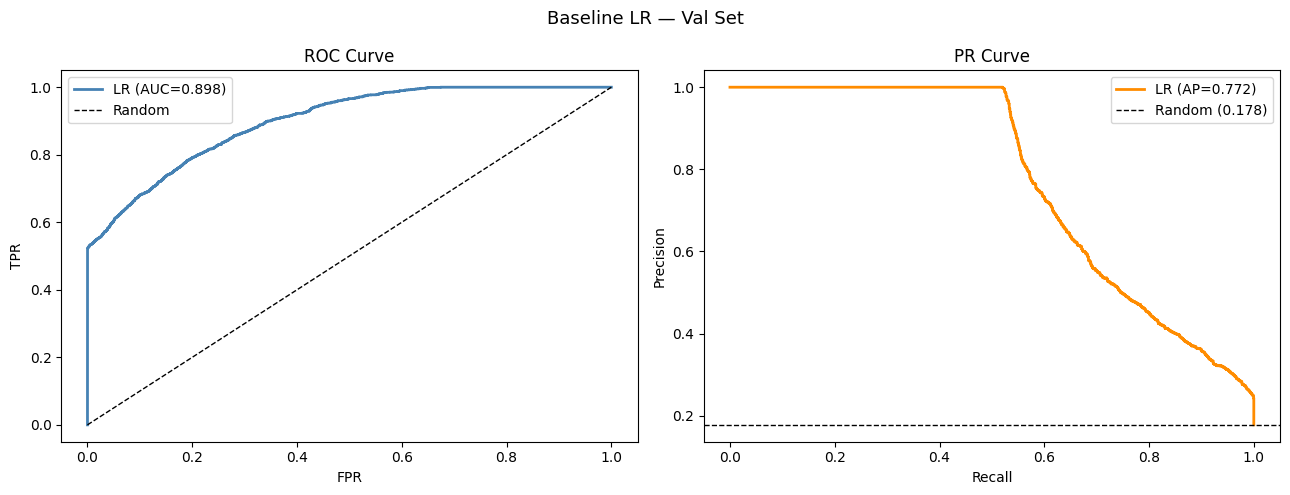

In [7]:
roc_auc_val = roc_auc_score(y_val, y_val_prob)
pr_auc_val  = average_precision_score(y_val, y_val_prob)
brier_val   = brier_score_loss(y_val, y_val_prob)

print(f'ROC-AUC  : {roc_auc_val:.4f}  (random = 0.50)')
print(f'PR-AUC   : {pr_auc_val:.4f}  (random = {y_val.mean():.4f})')
print(f'PR lift  : {pr_auc_val/y_val.mean():.2f}×')
print(f'Brier    : {brier_val:.4f}')

fpr, tpr, _ = roc_curve(y_val, y_val_prob)
prec, rec, _ = precision_recall_curve(y_val, y_val_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'LR (AUC={roc_auc_val:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'LR (AP={pr_auc_val:.3f})')
axes[1].axhline(y_val.mean(), color='k', ls='--', lw=1, label=f'Random ({y_val.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

plt.suptitle('Baseline LR — Val Set', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / '13_lr_roc_pr.png', dpi=150)
plt.show()


## 5. Calibration

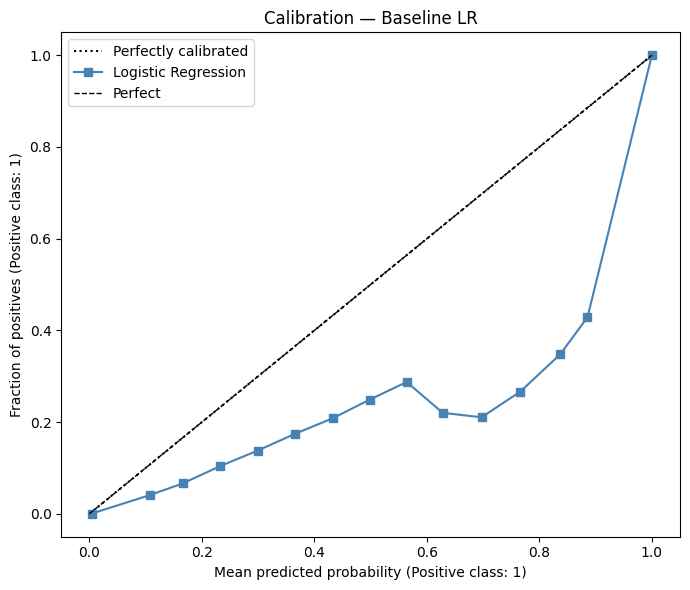

Brier score: 0.0923


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(y_val, y_val_prob, n_bins=15, ax=ax,
                                    name='Logistic Regression', color='steelblue')
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
ax.set_title('Calibration — Baseline LR'); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / '14_lr_calibration.png', dpi=150)
plt.show()
print(f'Brier score: {brier_val:.4f}')


## 6. Threshold Optimisation

Criterion                   τ    Prec     Rec      F1      Savings   Flagged
----------------------------------------------------------------------
Max savings             0.183   0.310   0.953   0.468 $   414,625     5,463
Max F1                  0.500   0.670   0.631   0.650 $   323,375     1,677

Selected threshold: 0.183


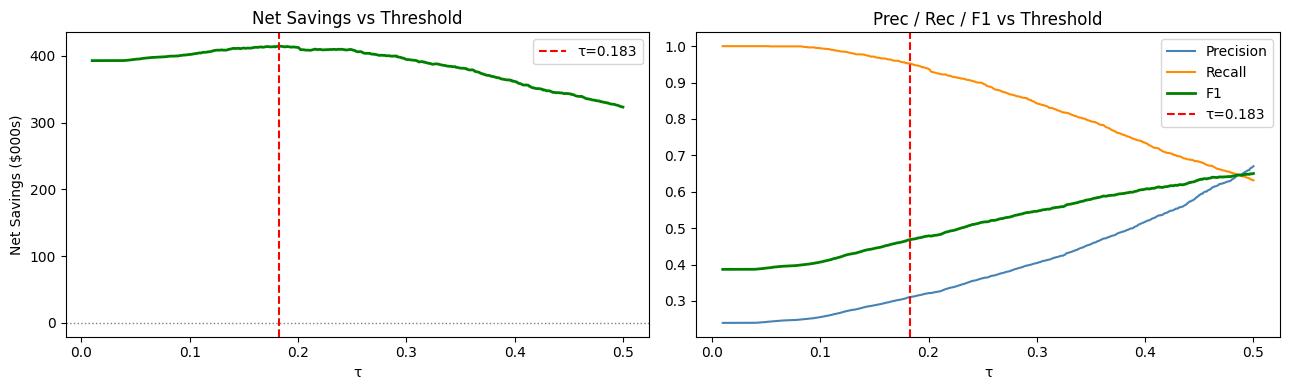

In [9]:
thresholds = np.linspace(0.01, 0.50, 500)
results = []
baseline_cost = y_val.sum() * FN_COST

for t in thresholds:
    yp = (y_val_prob >= t).astype(int)
    tp = ((yp==1)&(y_val==1)).sum(); fp = ((yp==1)&(y_val==0)).sum()
    fn = ((yp==0)&(y_val==1)).sum(); tn = ((yp==0)&(y_val==0)).sum()
    cost = fn*FN_COST + fp*FP_COST
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    results.append({'t':t,'tp':tp,'fp':fp,'fn':fn,'tn':tn,
                    'cost':cost,'savings':baseline_cost-cost,
                    'prec':prec,'rec':rec,'f1':f1,'flagged':tp+fp})

res = pd.DataFrame(results)
best_cost_row = res.loc[res['savings'].idxmax()]
best_f1_row   = res.loc[res['f1'].idxmax()]

print(f'{"Criterion":<22} {"τ":>6} {"Prec":>7} {"Rec":>7} {"F1":>7} {"Savings":>12} {"Flagged":>9}')
print('-'*70)
for label, row in [('Max savings', best_cost_row), ('Max F1', best_f1_row)]:
    print(f"{label:<22} {row['t']:>6.3f} {row['prec']:>7.3f} {row['rec']:>7.3f} "
          f"{row['f1']:>7.3f} ${row['savings']:>10,.0f} {row['flagged']:>9,.0f}")

OPTIMAL_THRESHOLD = best_cost_row['t']
print(f'\nSelected threshold: {OPTIMAL_THRESHOLD:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(res['t'], res['savings']/1000, color='green', lw=2)
axes[0].axvline(OPTIMAL_THRESHOLD, color='red', ls='--', label=f'τ={OPTIMAL_THRESHOLD:.3f}')
axes[0].axhline(0, color='gray', ls=':', lw=1)
axes[0].set_title('Net Savings vs Threshold'); axes[0].set_xlabel('τ')
axes[0].set_ylabel('Net Savings ($000s)'); axes[0].legend()

axes[1].plot(res['t'], res['prec'], label='Precision', color='steelblue')
axes[1].plot(res['t'], res['rec'],  label='Recall',    color='darkorange')
axes[1].plot(res['t'], res['f1'],   label='F1',        color='green', lw=2)
axes[1].axvline(OPTIMAL_THRESHOLD, color='red', ls='--', label=f'τ={OPTIMAL_THRESHOLD:.3f}')
axes[1].set_title('Prec / Rec / F1 vs Threshold'); axes[1].set_xlabel('τ'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES / '15_lr_threshold.png', dpi=150)
plt.show()


## 7. Confusion Matrix & Risk Categories

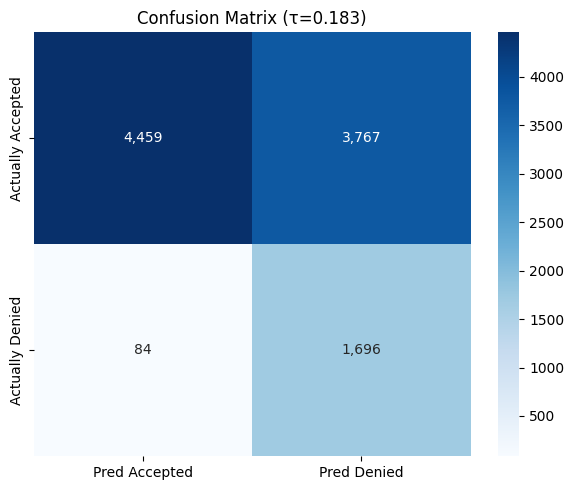

              precision    recall  f1-score   support

    Accepted       0.98      0.54      0.70      8226
      Denied       0.31      0.95      0.47      1780

    accuracy                           0.62     10006
   macro avg       0.65      0.75      0.58     10006
weighted avg       0.86      0.62      0.66     10006


Risk Category Summary:
           N  Denied   Rate  AvgProb
RISK                                
Low     4811     111 0.0231   0.0606
Medium  3966     669 0.1687   0.3539
High    1229    1000 0.8137   0.9231


In [10]:
y_val_pred = (y_val_prob >= OPTIMAL_THRESHOLD).astype(int)
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Pred Accepted','Pred Denied'],
            yticklabels=['Actually Accepted','Actually Denied'])
ax.set_title(f'Confusion Matrix (τ={OPTIMAL_THRESHOLD:.3f})')
plt.tight_layout()
plt.savefig(FIGURES / '16_lr_confusion.png', dpi=150)
plt.show()
print(classification_report(y_val, y_val_pred, target_names=['Accepted','Denied']))

# Risk categories
LOW, HIGH = cfg.evaluation.risk_thresholds.low, cfg.evaluation.risk_thresholds.high
cats = pd.cut(y_val_prob, bins=[0, LOW, HIGH, 1.0], labels=['Low','Medium','High'], include_lowest=True)
cat_df = pd.DataFrame({'RISK':cats, 'DENIED':y_val, 'PROB':y_val_prob})
summary = (cat_df.groupby('RISK', observed=True)
           .agg(N=('DENIED','count'), Denied=('DENIED','sum'), Rate=('DENIED','mean'), AvgProb=('PROB','mean'))
           .reindex(['Low','Medium','High'], fill_value=0))
print('\nRisk Category Summary:')
print(summary.to_string())


## 8. Top Coefficients

Top 20 features by |coefficient|:
               feature    coef
  BENE_DENIAL_RATE_90D  5.5104
  BENE_DENIAL_RATE_60D  2.8728
  BENE_DENIAL_RATE_30D  1.6258
 IS_HIGH_RISK_PROVIDER  0.3275
           SP_CHRNKIDN  0.2018
           SP_ISCHMCHT  0.1924
               SP_CNCR  0.1915
     COMORBIDITY_COUNT  0.1851
           SP_DIABETES  0.1640
PRVDR_CLAIM_VOLUME_LOG  0.1189
                SP_CHF  0.1176
           SP_DEPRESSN  0.1150
        HI_CVRAGE_MONS  0.1013
         CLAIM_QUARTER -0.0747
      DAYS_SINCE_START  0.0607
              SP_RA_OA  0.0456
PRVDR_DENIAL_RATE_HIST -0.0402
     BENE_AGE_AT_CLAIM -0.0393
            CLAIM_YEAR  0.0389
           CLAIM_MONTH  0.0367


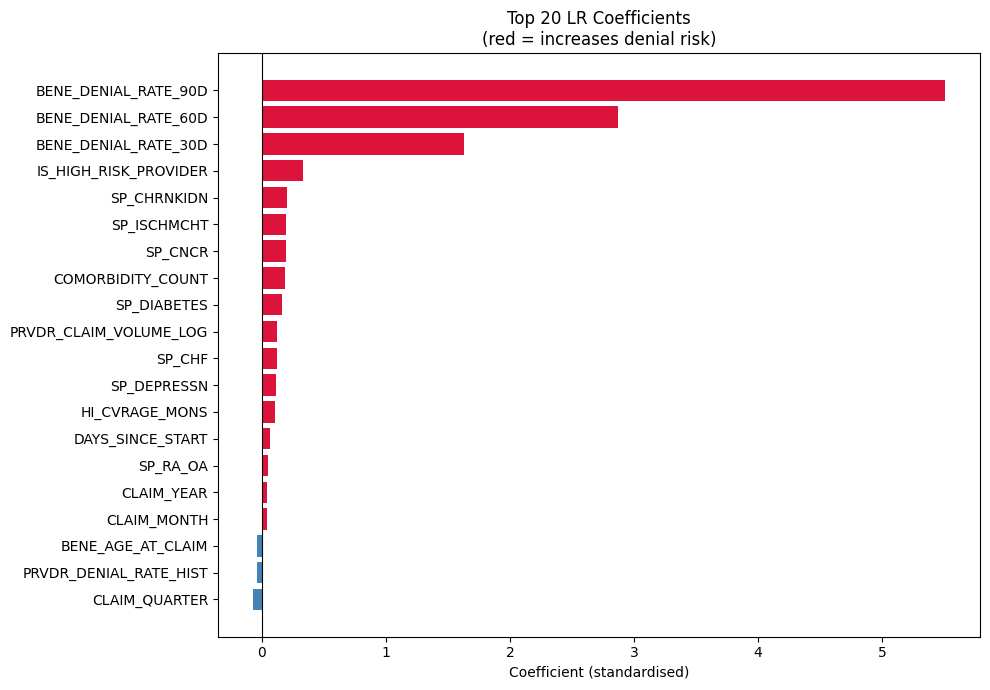

In [11]:
coefs = lr_pipeline.named_steps['lr'].coef_[0]
coef_df = pd.DataFrame({'feature': X_train.columns, 'coef': coefs,
                         'abs': np.abs(coefs)}).sort_values('abs', ascending=False)
print('Top 20 features by |coefficient|:')
print(coef_df.head(20)[['feature','coef']].to_string(index=False))

top20 = coef_df.head(20).sort_values('coef')
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(top20['feature'], top20['coef'],
        color=['crimson' if c>0 else 'steelblue' for c in top20['coef']])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 20 LR Coefficients\n(red = increases denial risk)')
ax.set_xlabel('Coefficient (standardised)')
plt.tight_layout()
plt.savefig(FIGURES / '18_lr_coefficients.png', dpi=150)
plt.show()


## 9. Test Set Results & Save

In [12]:
roc_auc_test = roc_auc_score(y_test, y_test_prob)
pr_auc_test  = average_precision_score(y_test, y_test_prob)
brier_test   = brier_score_loss(y_test, y_test_prob)

print('=' * 52)
print('  BASELINE LR — TEST SET RESULTS')
print('=' * 52)
print(f'  ROC-AUC : {roc_auc_test:.4f}  (random = 0.50)')
print(f'  PR-AUC  : {pr_auc_test:.4f}  (random = {y_test.mean():.4f})')
print(f'  PR lift : {pr_auc_test/y_test.mean():.2f}×  over random')
print(f'  Brier   : {brier_test:.4f}')
print()
for label, tau in [('Cost-optimal', OPTIMAL_THRESHOLD), ('Max-F1', float(best_f1_row["t"]))]:
    yp = (y_test_prob >= tau).astype(int)
    tp_ = ((yp==1)&(y_test==1)).sum(); fp_ = ((yp==1)&(y_test==0)).sum()
    fn_ = ((yp==0)&(y_test==1)).sum()
    prec = tp_/(tp_+fp_) if (tp_+fp_)>0 else 0
    rec  = tp_/(tp_+fn_) if (tp_+fn_)>0 else 0
    sav  = y_test.sum()*FN_COST - (fn_*FN_COST + fp_*FP_COST)
    print(f'  {label} (τ={tau:.3f}): Prec={prec:.3f}  Rec={rec:.3f}  '
          f'Caught={tp_:,}/{y_test.sum():,}  Savings=${sav:,.0f}')
print('=' * 52)

# Save
joblib.dump(lr_pipeline, MODELS / 'baseline_lr.joblib')
joblib.dump(OPTIMAL_THRESHOLD, MODELS / 'baseline_lr_threshold.joblib')
report = {
    'model': 'Logistic Regression (Baseline)',
    'label': 'secondary_payer',
    'val':  {'roc_auc': round(roc_auc_val,4), 'pr_auc': round(pr_auc_val,4), 'brier': round(brier_val,4)},
    'test': {'roc_auc': round(roc_auc_test,4), 'pr_auc': round(pr_auc_test,4), 'brier': round(brier_test,4)},
    'optimal_threshold': round(float(OPTIMAL_THRESHOLD),4),
    'targets': {'roc_auc': '> 0.80', 'pr_auc': f'> {round(pr_auc_test*2,4)}'},
}
with open(REPORTS / 'baseline_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f'\n✓ Saved model + report.')
print(f'  Target for NB04 — ROC-AUC > 0.80  |  PR-AUC > {pr_auc_test*2:.4f}')


  BASELINE LR — TEST SET RESULTS
  ROC-AUC : 0.8814  (random = 0.50)
  PR-AUC  : 0.7318  (random = 0.1558)
  PR lift : 4.70×  over random
  Brier   : 0.0948

  Cost-optimal (τ=0.183): Prec=0.263  Rec=0.938  Caught=1,463/1,559  Savings=$336,450
  Max-F1 (τ=0.500): Prec=0.614  Rec=0.613  Caught=956/1,559  Savings=$271,800

✓ Saved model + report.
  Target for NB04 — ROC-AUC > 0.80  |  PR-AUC > 1.4636
